# Notebook for handcrafted feature Baseline prediction evaluation

In [16]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
from src.metrics.handcrafted_metrics import compute_extended_hand_metrics, analyze_metrics_vs_grs

In [21]:
df_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="data/processed/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_extended_hand_metrics,
    fps=30,
    correlation="spearman",
    end = "10fps_processed.pkl"
)

100%|██████████| 86/86 [00:57<00:00,  1.49it/s]


In [3]:
df_metrics['interaction_Right'] = df_metrics['total_path_Right'] * df_metrics['total_duration_Right'] * df_metrics['mean_disp_Right']
df_metrics['interaction_Left'] = df_metrics['total_path_Left'] * df_metrics['total_duration_Left'] * df_metrics['mean_disp_Left']

df_metrics.drop(['intermittency_ratio_Right', 'intermittency_ratio_Left'], axis=1, inplace=True)
#df[['mult','total_path_Right' ,'mean_disp_Right', 'total_duration_Right', 'QRS_Overal']].describe()

In [4]:
df_metrics.sort_values(by='fraction_tracked_Right')[['Participant Number', 'Case_Number', 'fraction_tracked_Right', 'total_path_Right', 'adjusted_total_path_Right', 'QRS_Overal']]

,Participant Number,Case_Number,fraction_tracked_Right,total_path_Right,adjusted_total_path_Right,QRS_Overal
57,21,2,0.532727,27610.980325,51829.485252,38.25
69,25,2,0.585292,30450.422442,52026.016531,51.75
37,14,2,0.625072,21384.184344,34210.742236,66.25
38,14,3,0.632855,32152.515505,50805.491454,67.75
34,13,2,0.671076,30093.610653,44843.794370,55.50
...,...,...,...,...,...,...
4,2,2,0.870103,64686.135080,74343.087367,38.00
50,18,3,0.870592,55961.201611,64279.492234,43.25
2,1,3,0.870922,44734.639261,51364.691660,60.50
51,19,1,0.894349,87066.378378,97351.692308,35.50


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_correlations(correlations_dict, title="Correlation with GRS_Total"):
    """
    Plot correlations as a bar chart with correlation values on top.
    
    Parameters
    ----------
    correlations_dict : dict
        Dictionary of correlations, format: {metric_name: {'correlation': r, 'p_value': p}}
    title : str
        Plot title
    """
    metrics = list(correlations_dict.keys())
    corrs = [v['correlation'] for v in correlations_dict.values()]
    pvals = [v['p_value'] for v in correlations_dict.values()]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, corrs, color='skyblue')
    plt.ylabel("Pearson Correlation with GRS_Total")
    plt.title(title)
    
    # Show correlation and p-value on top of bars
    for i, (r, p) in enumerate(zip(corrs, pvals)):
        plt.text(i, r, f"{r:.2f}\n(p={p:.2g})", ha='center', va='bottom' if r>=0 else 'top', fontsize=8)
    
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.ylim(-0.8, 0.8)
    plt.show()

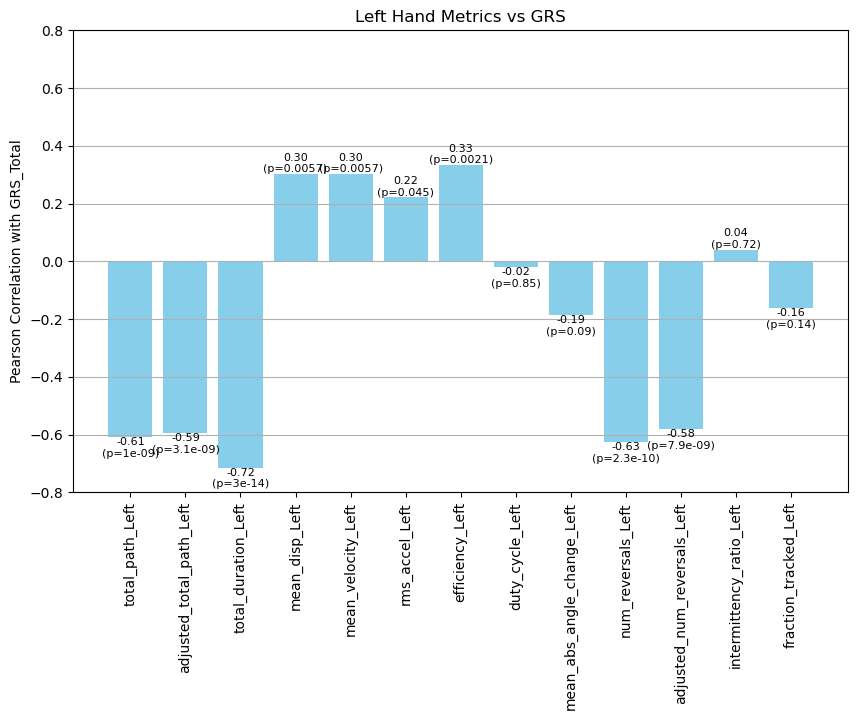

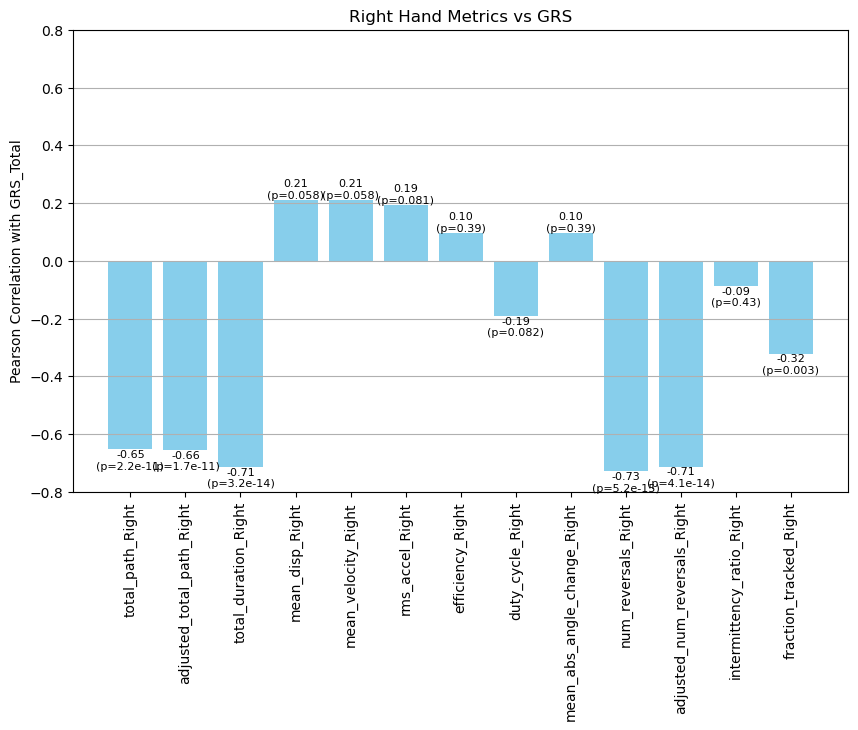

In [20]:
# Left-hand plot
left_metrics = [c for c in df_metrics.columns if c.endswith("_Left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics.columns if c.endswith("_Right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

In [14]:
cols = ['total_path_Left',
 'total_duration_Left',
 'mean_velocity_Left',
 'rms_accel_Left',
 'efficiency_Left',
 'num_reversals_Left',
 'total_path_Right',
 'total_duration_Right',
 'rms_accel_Right',
 'duty_cycle_Right',
 'mean_abs_angle_change_Right',
 'num_reversals_Right']

/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is 

Worst prediction for Participant 19, Case 2 with error 10.86  (True: 33.75, Predicted: 44.61)
Worst prediction for Participant 3, Case 1 with error 10.87  (True: 62.00, Predicted: 51.13)
Worst prediction for Participant 18, Case 2 with error 11.08  (True: 35.50, Predicted: 46.58)
Worst prediction for Participant 7, Case 1 with error 11.31  (True: 44.00, Predicted: 55.31)
Worst prediction for Participant 16, Case 2 with error 11.51  (True: 41.25, Predicted: 52.76)
Worst prediction for Participant 14, Case 3 with error 13.08  (True: 67.75, Predicted: 54.67)
Worst prediction for Participant 1, Case 2 with error 14.09  (True: 45.00, Predicted: 59.09)
Worst prediction for Participant 16, Case 3 with error 14.26  (True: 58.75, Predicted: 44.49)
Worst prediction for Participant 7, Case 3 with error 15.43  (True: 41.25, Predicted: 56.68)
Worst prediction for Participant 21, Case 2 with error 16.47  (True: 38.25, Predicted: 54.72)
LOOCV MAE: 5.08 vs Naive MAE: 7.81
LOOCV SD: 6.49 vs Naive SD: 9

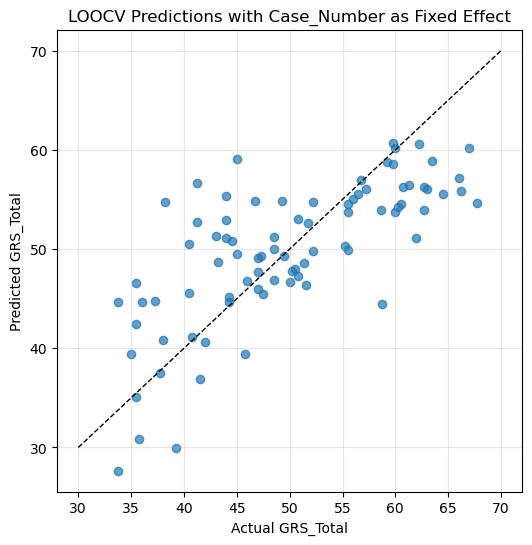

In [25]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Step 1: Prepare metrics ---
metrics = [col for col in df_metrics.columns if 'Right' in col]# or 'left' in col]
metrics = ["adjusted_total_path_Right", "total_duration_Right", "adjusted_num_reversals_Right", "mean_abs_angle_change_Right"]
#metrics = cols
#metrics.extend(['interhand_dist_change_rms'])

# Standardize metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_metrics[metrics])
X_scaled = pd.DataFrame(X_scaled, columns=metrics)
df_metrics_scaled = pd.concat([df_metrics[['Participant Number', 'GRS_Total', 'QRS_Overal', 'Case_Number']], X_scaled], axis=1)
#df_metrics_scaled['adjusted_total_path_right'] = df_metrics_scaled['total_path_right']*df_metrics['tracking_fraction_right']  # keep unscaled for reference
#df_metrics_scaled['adjusted_total_path_left'] = df_metrics_scaled['total_path_left']*df_metrics['tracking_fraction_left']  # keep unscaled for reference
#df_metrics_scaled.drop(columns=['total_path_right', 'tracking_fraction_right'], inplace=True)
#metrics.remove('total_path_right')
#metrics.remove('tracking_fraction_right')
#metrics.append('adjusted_total_path_right')
# --- Step 2: Compute PCA components ---
pca = PCA(n_components=4)
X_pcs = pca.fit_transform(df_metrics_scaled[metrics])

for i in range(4):
    df_metrics_scaled[f'PC{i+1}'] = X_pcs[:, i]

# --- Step 3: LOOCV setup ---
participants = df_metrics_scaled['Participant Number'].unique()
y_true = []
y_pred = []
case_number = []

for p in participants:
    train_df = df_metrics_scaled[df_metrics_scaled['Participant Number'] != p]
    test_df = df_metrics_scaled[df_metrics_scaled['Participant Number'] == p]

    # keep track of the file

    # --- Step 4: Mixed Linear Model with Case_Number as fixed effect ---
    model = smf.mixedlm(
        f"QRS_Overal ~ PC1 + PC2 + PC3",
        train_df,
        groups=train_df["Participant Number"],
        vc_formula={"Case": "0 + C(Case_Number)"}
    )
    results = model.fit()

    # Predict for the left-out participant
    pred = results.predict(test_df)
    y_true.extend(test_df['QRS_Overal'].values)
    y_pred.extend(pred.values)
    case_number.extend(test_df['Case_Number'].values)

# --- Step 5: Evaluate performance ---
y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
sd = np.std(y_pred - y_true)
corr = np.corrcoef(y_true, y_pred)[0, 1]

# --- Identify worst prediction ---
errors = np.abs(y_true - y_pred)
# worst 10 predictions
worst_indices = np.argsort(errors)[-10:]
worst_participants = df_metrics_scaled.iloc[worst_indices][['Participant Number', 'Case_Number']]
for worst_idx in worst_indices:
    print(f"Worst prediction for Participant {worst_participants.loc[worst_idx, 'Participant Number']}, Case {worst_participants.loc[worst_idx, 'Case_Number']} with error {errors[worst_idx]:.2f}",
          f" (True: {y_true[worst_idx]:.2f}, Predicted: {y_pred[worst_idx]:.2f})")

# Naive mean predictor but per case number
mean_pred_case_1 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 1]['QRS_Overal'])
mean_pred_case_2 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 2]['QRS_Overal'])
mean_pred_case_3 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 3]['QRS_Overal'])

mean_case_preds = [mean_pred_case_1, mean_pred_case_2, mean_pred_case_3]
naive_case_preds = [mean_case_preds[cn-1] for cn in case_number]
naive_mae = np.mean(np.abs(y_true - naive_case_preds))
naive_sd = np.std(np.array(naive_case_preds) - y_true)

print(f"LOOCV MAE: {mae:.2f} vs Naive MAE: {naive_mae:.2f}")
print(f"LOOCV SD: {sd:.2f} vs Naive SD: {naive_sd:.2f}")
print(f"LOOCV Correlation: {corr:.2f}")

# --- Step 6: Visualization ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([30, 70], [30, 70], 'k--', lw=1)
plt.xlabel("Actual GRS_Total")
plt.ylabel("Predicted GRS_Total")
plt.title("LOOCV Predictions with Case_Number as Fixed Effect")
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
df_metrics_scaled.head()

,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,adjusted_num_reversals_Right,mean_abs_angle_change_Right,PC1,PC2,PC3,PC4
0,1,59.25,48.50,1,0.184805,-0.142009,0.292954,-0.953573,0.487489,-0.793460,0.334092,0.265710
1,1,54.40,45.00,2,-1.103816,-1.323120,-1.209565,0.926496,-2.287117,0.224301,0.090565,0.032884
2,1,74.50,60.50,3,-0.372264,-0.677312,-0.249396,1.248647,-1.109647,0.967259,0.037255,0.224401
3,2,49.25,39.25,1,2.354580,3.429551,3.416177,-0.951941,5.351349,0.689718,-0.832712,0.276171
4,2,49.00,38.00,2,0.827446,2.134585,1.317910,-1.083350,2.697762,-0.369234,-0.824595,-0.239678


In [34]:
df_metrics_scaled[['Participant Number', 'Case_Number', 'PC1', 'PC2', 'PC3', 'QRS_Overal']].to_csv("data/metrics/total_metrics_pca.csv", index=False)


# Version below with no data leakage in PCA
- Result is similar!

/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is 

LOOCV MAE: 5.07, RMSE: 6.48, SD: 6.48, Correlation: 0.72


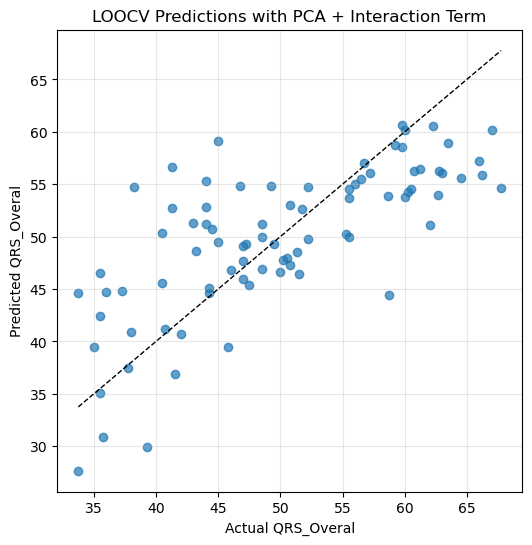

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Step 0: Define metrics and interaction ---
metrics = ["adjusted_total_path_Right", "total_duration_Right", "adjusted_num_reversals_Right", "mean_abs_angle_change_Right"]

# --- Step 1: LOOCV setup ---
participants = df_metrics['Participant Number'].unique()
y_true = []
y_pred = []
case_number = []

for p in participants:
    # --- Split train/test ---
    train_df = df_metrics[df_metrics['Participant Number'] != p].copy()
    test_df = df_metrics[df_metrics['Participant Number'] == p].copy()

    # --- Standardize metrics on training data ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_df[metrics])
    X_test_scaled = scaler.transform(test_df[metrics])

    df_train_scaled = pd.DataFrame(X_train_scaled, columns=metrics, index=train_df.index)
    df_test_scaled = pd.DataFrame(X_test_scaled, columns=metrics, index=test_df.index)

    # --- PCA on scaled training metrics ---
    pca = PCA(n_components=min(len(metrics), 4))
    pcs_train = pca.fit_transform(df_train_scaled)
    pcs_test = pca.transform(df_test_scaled)

    # Add PCs to train/test DataFrames
    for i in range(pcs_train.shape[1]):
        df_train_scaled[f'PC{i+1}'] = pcs_train[:, i]
        df_test_scaled[f'PC{i+1}'] = pcs_test[:, i]

    # Add target and metadata
    df_train_scaled['QRS_Overal'] = train_df['QRS_Overal']
    df_train_scaled['Participant'] = train_df['Participant Number']
    df_train_scaled['Case_Number'] = train_df['Case_Number']

    df_test_scaled['QRS_Overal'] = test_df['QRS_Overal']
    df_test_scaled['Participant'] = test_df['Participant Number']
    df_test_scaled['Case_Number'] = test_df['Case_Number']

    # --- Create interaction manually on scaled features ---
    #df_train_scaled['inter1'] = df_train_scaled['adjusted_total_path_Right'] * df_train_scaled['mean_abs_angle_change_Right']
    #df_test_scaled['inter1'] = df_test_scaled['adjusted_total_path_Right'] * df_test_scaled['mean_abs_angle_change_Right']

    # --- Step 2: Fit LMM ---
    model = smf.mixedlm(
        "QRS_Overal ~ PC1 + PC2 + PC3",
        df_train_scaled,
        groups=df_train_scaled["Participant"],
        vc_formula={"Case": "0 + C(Case_Number)"}
    )
    results = model.fit()

    # --- Step 3: Predict on test participant ---
    pred = results.predict(df_test_scaled)
    y_true.extend(df_test_scaled['QRS_Overal'].values)
    y_pred.extend(pred.values)
    case_number.extend(df_test_scaled['Case_Number'].values)

# --- Step 4: Evaluate performance ---
y_true = np.array(y_true)
y_pred = np.array(y_pred)
errors = np.abs(y_true - y_pred)

mae = np.mean(errors)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
sd = np.std(y_pred - y_true)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print(f"LOOCV MAE: {mae:.2f}, RMSE: {rmse:.2f}, SD: {sd:.2f}, Correlation: {corr:.2f}")

# --- Step 5: Visualization ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'k--', lw=1)
plt.xlabel("Actual QRS_Overal")
plt.ylabel("Predicted QRS_Overal")
plt.title("LOOCV Predictions with PCA + Interaction Term")
plt.grid(True, alpha=0.3)
plt.show()
